# Dokumentasi Riset Data Science
## Sistem AI Monitoring dan Prediksi Fluks Karbon Berbasis IoT

**Perangkat IoT:** `AGRISENSE-CC-001`  
**Model terbaik saat ini:** `RandomForestRegressor` dengan **R2 = 0.613** pada Skenario A  
**Lokasi dataset:** Mead, Nebraska, USA  
**Target variabel:** `carbon_flux` (NEE / FC)

Notebook ini mendokumentasikan **Skenario B**, yaitu penambahan fitur tanah statis dari WoSIS ke pipeline prediksi `carbon_flux`. Fokusnya adalah menguji apakah konteks tanah berupa **pH** dan **soil organic carbon (SOC)** dapat meningkatkan performa baseline berbasis fitur dinamis time-series dari AmeriFlux.


## BAB 1 - Latar Belakang dan Tujuan Proyek

Perangkat IoT lapangan seperti `AGRISENSE-CC-001` mampu membaca parameter lingkungan dan tanah secara real-time, tetapi tidak mengukur fluks karbon secara langsung. Karena itu, proyek ini menggunakan pendekatan machine learning untuk memperkirakan `carbon_flux` dari pola cuaca, kondisi tanah, dan waktu pengamatan.

### Tujuan utama
- Membangun model prediksi `carbon_flux` berbasis sensor IoT real-time.
- Membandingkan performa `RandomForestRegressor` dan `XGBoostRegressor`.
- Mengintegrasikan data dinamis time-series (AmeriFlux) dengan data statis spasial (WoSIS).
- Menyiapkan model terbaik untuk integrasi ke backend Laravel.

### Skenario eksperimen
| Skenario | Nama | Deskripsi singkat |
| --- | --- | --- |
| A | Baseline | Fitur dinamis sensor + waktu, seluruh kolom `_QC` dihapus. Model terbaik: Random Forest dengan `R2 = 0.613`. |
| B | Statis Tunggal | Menambahkan `soil_ph` dan `soil_organic_carbon` untuk satu lokasi `US-Ne1`. Karena nilainya konstan pada seluruh baris site, kontribusinya diperkirakan rendah. |
| C | Multi-Site | Menggabungkan `US-Ne1`, `US-Ne2`, dan `US-Ne3` agar model bisa belajar dari variasi tanah antar lahan. |


## BAB 2 - Dataset yang Dibutuhkan

### 2.1 Dataset utama: AmeriFlux (dinamis time-series)
AmeriFlux berfungsi sebagai sumber utama pembelajaran model karena menyediakan data half-hourly lingkungan dan fluks karbon.

| Site ID | Nama lokasi | Jenis lahan | DOI |
| --- | --- | --- | --- |
| `US-Ne1` | Mead - Irrigated Continuous Maize | Jagung irigasi penuh | `10.17190/AMF/1246084` |
| `US-Ne2` | Mead - Irrigated Maize-Soybean Rotation | Jagung-kedelai irigasi | `10.17190/AMF/1246085` |
| `US-Ne3` | Mead - Rainfed Maize-Soybean Rotation | Jagung-kedelai tadah hujan | `10.17190/AMF/1246086` |

Fakta penting:
- Ketiga site berada sangat berdekatan di University of Nebraska Agricultural Research and Development Center.
- Resolusi data adalah **half-hourly (30 menit)**.
- Lisensi data AmeriFlux BASE adalah **CC-BY-4.0**.

### Kolom kunci yang digunakan
| Kolom AmeriFlux | Harmonisasi | Peran |
| --- | --- | --- |
| `FC` atau `FC_F` | `carbon_flux` | Target variabel utama |
| `NEE_VUT_REF` | `carbon_flux` | Alternatif target gap-filled |
| `TA_F` | `air_temperature_c` | Suhu udara |
| `RH` | `relative_humidity` | Kelembapan relatif |
| `TS_F_MDS_1` | `soil_temperature_c` | Suhu tanah |
| `SWC_F_MDS_1` | `soil_water_content` | Kelembapan tanah |
| `SW_IN` | `solar_radiation` | Radiasi surya masuk |
| `TIMESTAMP_START` | waktu dasar | Sumber fitur `hour`, `day_of_year`, `month` |

### 2.2 Dataset pendukung: WoSIS ISRIC (statis spasial)
WoSIS menyediakan konteks tanah yang tidak berubah cepat terhadap waktu.

| File | Properti tanah | Satuan | Penggunaan |
| --- | --- | --- | --- |
| `wosis_latest_PH` | pH tanah | skala pH | fitur `soil_ph` |
| `wosis_latest_orgc` | soil organic carbon | g/kg fine earth | fitur `soil_organic_carbon` |

Metode integrasi yang benar adalah **nearest-neighbor spatial join**, bukan penggabungan langsung per baris waktu.

### Dataset yang harus dihindari
- File AmeriFlux berakhiran `_QC` karena berisiko menyebabkan data leakage.
- File `ERA5_`, `BIF_`, dan `AUXMETEO_` karena bukan data sensor lapangan murni.
- Dataset luar Nebraska atau dataset CO2 indoor karena akan menciptakan bias ilmiah.


## BAB 3 - Alur Preprocessing Dataset

### Jalur A: AmeriFlux dinamis
1. Memuat file `AMF_{SITE_ID}_BASE_HH_{VERSION}.csv`.
2. Mengganti sentinel `-9999` menjadi `NaN`.
3. Menghapus seluruh kolom berakhiran `_QC`.
4. Melakukan harmonisasi nama kolom ke skema sensor IoT.
5. Mengekstrak fitur waktu dari `TIMESTAMP_START`.
6. Menambahkan identitas `site_id` untuk eksperimen multi-site.

### Jalur B: WoSIS statis
1. Memuat file pH dan SOC dari WoSIS.
2. Memfilter area Nebraska dan menghitung jarak terhadap koordinat site AmeriFlux.
3. Mengambil rata-rata 5 sampai 10 profil terdekat.
4. Menyusun dictionary nilai statis per `site_id`.

### Integrasi dan splitting
1. Melakukan broadcasting nilai tanah statis ke seluruh baris time-series sesuai `site_id`.
2. Menghapus baris yang masih memiliki `NaN` pada fitur penting dan target.
3. Melakukan split kronologis `80% train` dan `20% test`.

**Catatan penting:** split harus berbasis waktu, bukan acak, agar informasi masa depan tidak bocor ke data latih.


## BAB 4 - Analisis Korelasi Variabel terhadap Carbon Flux

| Variabel | Arah | Kekuatan | Makna ilmiah |
| --- | --- | --- | --- |
| `SW_IN` / PAR | Negatif kuat | `r ~ -0.80` s.d. `-0.90` di siang hari | Driver utama fotosintesis |
| Suhu tanah (`TS_F`) | Positif kuat | tinggi | Mengontrol respirasi mikroba tanah |
| Suhu udara (`TA_F`) | Positif non-linear | kuat | Mendukung GPP hingga batas heat stress |
| Kelembapan tanah (`SWC`) | Positif moderat | `r ~ 0.44-0.47` | Mempengaruhi penyerapan dan respirasi |
| RH / VPD | Negatif via VPD | kuat | VPD tinggi menutup stomata |
| `hour` | Kontekstual | sangat kuat | Membedakan siang vs malam |
| `month` | Kontekstual | sangat kuat | Menangkap siklus musiman |
| `soil_ph` dan `SOC` | Lemah di single-site | rendah | Baru bernilai saat ada variasi antar site |

### Persamaan inti
`NEE = Ra + Rh - GPP`

- `NEE` negatif berarti lahan berfungsi sebagai **carbon sink**.
- `NEE` positif berarti lahan berfungsi sebagai **carbon source**.
- `Rh` sangat dipengaruhi suhu tanah dan kelembapan tanah.
- `GPP` sangat dipengaruhi radiasi, suhu, dan kondisi stomata tanaman.


## BAB 5 - Diagram Konseptual Siklus Karbon

```text
[ ATMOSFER CO2 ]
  ^  NEE positif (carbon source)
  |  Rh + Ra
  |
  |  GPP
  v  NEE negatif (carbon sink)
[ TANAMAN / KANOPI JAGUNG ]
  - Fotosintesis dikontrol oleh PAR, suhu udara, dan VPD
  - Serasah dan akar mati memasok karbon ke tanah
              |
              v
[ TANAH: SOC + MIKROBA ]
  - Respirasi heterotropik dikontrol oleh soil_temperature dan soil_water_content
  - SOC tinggi menyediakan substrat karbon untuk dekomposisi
```

### Siang vs malam
| Kondisi | Mekanisme dominan | Konsekuensi pada NEE |
| --- | --- | --- |
| Siang (`PAR > 0`) | Fotosintesis aktif, `GPP > Ra + Rh` | NEE cenderung negatif |
| Malam (`PAR = 0`) | Hanya respirasi `Ra + Rh` | NEE cenderung positif |


## BAB 6 - Implikasi untuk Model dan Pengembangan Lanjutan

### Prioritas fitur yang didukung sains dan eksperimen
1. `SW_IN` / PAR sebagai driver langsung fotosintesis.
2. `soil_temperature` sebagai pengendali respirasi mikroba dan fitur dominan pada baseline.
3. `air_temperature` karena efeknya kuat namun non-linear.
4. `soil_water_content` sebagai pengendali variabilitas karbon jangka panjang.
5. `relative_humidity` atau turunan `VPD` untuk efek stomata.
6. `hour` dan `month` untuk menangkap pola diurnal dan musiman.
7. `soil_ph` dan `soil_organic_carbon` terutama relevan pada eksperimen multi-site.

### Interpretasi Skenario B
Pada notebook ini, `soil_ph` dan `soil_organic_carbon` dibroadcast sebagai nilai konstan untuk seluruh baris `US-Ne1`. Secara statistik, fitur konstan tidak memberi banyak variasi tambahan kepada model, sehingga hasil Skenario B lebih cocok dibaca sebagai **uji integrasi data statis**, bukan bukti bahwa pH dan SOC tidak penting secara ilmiah.

### Rekomendasi praktis
- Pastikan sensor atau proxy `SW_IN` tersedia dalam payload IoT produksi.
- Pertahankan fitur waktu seperti `hour` dan `month`.
- Untuk Skenario C, gabungkan `US-Ne1`, `US-Ne2`, dan `US-Ne3` agar fitur statis tanah memiliki varians antar lokasi.
- Jangan memasukkan kolom `_QC`, walaupun metrik mungkin tampak meningkat.


## BAB 7 - Referensi dan Checklist Eksekutif

### Referensi dataset
- AmeriFlux BASE `US-Ne1`: `10.17190/AMF/1246084`
- AmeriFlux BASE `US-Ne2`: `10.17190/AMF/1246085`
- AmeriFlux BASE `US-Ne3`: `10.17190/AMF/1246086`
- WoSIS snapshot 2023: `10.5194/essd-16-4735-2024`

### Referensi ilmiah pendukung
- Humphrey et al. (2021), *Nature*: soil moisture-atmosphere feedback dan variabilitas carbon uptake.
- Crowther et al. (2016), *Science*: respons fluks karbon tanah terhadap warming.
- Literatur SOC global dan dinamika respirasi tanah untuk interpretasi hubungan `Rh`, `SOC`, dan suhu tanah.

### Checklist aksi proyek
- [ ] Unduh data AmeriFlux `US-Ne1`, `US-Ne2`, dan `US-Ne3`.
- [ ] Unduh data WoSIS untuk pH dan SOC.
- [ ] Jalankan preprocessing: `-9999 -> NaN`, hapus `_QC`, harmonisasi kolom.
- [ ] Lakukan spatial join WoSIS ke site AmeriFlux.
- [ ] Latih dan evaluasi model dengan split kronologis.
- [ ] Ekspor model terbaik ke `.pkl` untuk integrasi Laravel.


In [1]:
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score

pd.set_option('display.max_columns', 200)


In [2]:
# =========================
# Utility Functions
# =========================
def evaluate_regression(y_true, y_pred):
    return {
        'MAE': mean_absolute_error(y_true, y_pred),
        'RMSE': root_mean_squared_error(y_true, y_pred),
        'R2': r2_score(y_true, y_pred),
    }


def haversine_km(lat1, lon1, lat2, lon2):
    """Approximate great-circle distance in kilometers."""
    r = 6371.0
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat / 2) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2) ** 2
    c = 2 * np.arcsin(np.sqrt(a))
    return r * c


def detect_column(df, candidates):
    """Find first matching column (case-insensitive) from candidate names."""
    lower_map = {c.lower(): c for c in df.columns}
    for cand in candidates:
        if cand.lower() in lower_map:
            return lower_map[cand.lower()]
    return None


def plot_feature_importance(model, feature_names, title='Feature Importance'):
    if not hasattr(model, 'feature_importances_'):
        raise ValueError('Model tidak memiliki atribut feature_importances_.')

    fi_df = pd.DataFrame({
        'feature': feature_names,
        'importance': model.feature_importances_
    }).sort_values('importance', ascending=False)

    plt.figure(figsize=(10, 6))
    sns.barplot(data=fi_df, x='importance', y='feature', orient='h')
    plt.title(title)
    plt.tight_layout()
    plt.show()

    return fi_df


In [3]:
# =========================
# Scenario A Clean Data Loader (reusable for Scenario B)
# =========================
def load_and_prepare_ameriflux(csv_path):
    raw_df = pd.read_csv(csv_path)
    df = raw_df.copy()

    # Missing value sentinel
    df = df.replace(-9999, np.nan)

    # Mapping to IoT schema
    col_mapping = {}
    for col in df.columns:
        if col == 'TIMESTAMP_START':
            col_mapping[col] = 'reading_time'
        elif col.startswith('TA_'):
            col_mapping[col] = 'air_temperature_sensor_' + col.split('_', 1)[-1]
        elif col == 'RH':
            col_mapping[col] = 'air_humidity_sensor'
        elif col.startswith('TS_'):
            col_mapping[col] = 'soil_temperature_' + col.split('_', 1)[-1]
        elif col.startswith('SWC_'):
            col_mapping[col] = 'soil_moisture_' + col.split('_', 1)[-1]
        elif col == 'NEE_VUT_REF':
            col_mapping[col] = 'carbon_flux'
        else:
            col_mapping[col] = col

    df = df.rename(columns=col_mapping)

    # Remove QC flags to prevent leakage
    qc_cols = [c for c in df.columns if '_QC' in c]
    if qc_cols:
        df = df.drop(columns=qc_cols)

    # Time features
    df['reading_time'] = pd.to_datetime(df['reading_time'], errors='coerce', format='%Y%m%d%H%M')
    df['hour'] = df['reading_time'].dt.hour
    df['day'] = df['reading_time'].dt.day
    df['month'] = df['reading_time'].dt.month

    main_features = [
        c for c in df.columns
        if c.startswith('air_temperature_sensor')
        or c == 'air_humidity_sensor'
        or c.startswith('soil_temperature')
        or c.startswith('soil_moisture')
    ]
    time_features = ['hour', 'day', 'month']
    target = 'carbon_flux'

    # Drop rows without required predictors/target
    clean_df = df.dropna(subset=main_features + time_features + [target, 'reading_time']).copy()
    clean_df = clean_df.sort_values('reading_time').reset_index(drop=True)

    print(f'Raw shape: {raw_df.shape}')
    print(f'Clean shape: {clean_df.shape}')
    print(f'QC columns removed: {len(qc_cols)}')

    return clean_df, main_features, time_features, target


In [4]:
# =========================
# WoSIS Spatial Extraction
# =========================
def extract_wosis_value_nearest(wosis_path, site_lat, site_lon, label, top_k=5):
    df = pd.read_csv(wosis_path)

    value_col = detect_column(df, ['value_avg', 'value', 'mean_value'])
    lat_col = detect_column(df, ['latitude', 'lat', 'y'])
    lon_col = detect_column(df, ['longitude', 'lon', 'long', 'x'])

    if value_col is None:
        raise ValueError(f'Kolom nilai tidak ditemukan di {wosis_path.name}.')

    work = df.copy()
    work[value_col] = pd.to_numeric(work[value_col], errors='coerce')
    work = work.dropna(subset=[value_col])

    if lat_col and lon_col:
        work[lat_col] = pd.to_numeric(work[lat_col], errors='coerce')
        work[lon_col] = pd.to_numeric(work[lon_col], errors='coerce')
        work = work.dropna(subset=[lat_col, lon_col])

        work['distance_km'] = haversine_km(site_lat, site_lon, work[lat_col], work[lon_col])
        nearest = work.nsmallest(top_k, 'distance_km').copy()
        extracted_value = nearest[value_col].mean()
        min_distance = nearest['distance_km'].min()

        print(f'[{label}] Source: {wosis_path.name}')
        print(f'[{label}] Value column: {value_col}')
        print(f'[{label}] Lat/Lon columns: {lat_col}, {lon_col}')
        print(f'[{label}] Top-{top_k} nearest mean: {extracted_value:.4f}')
        print(f'[{label}] Minimum distance: {min_distance:.2f} km')

        return extracted_value, min_distance, nearest

    # Fallback when coordinates are unavailable in source file
    country_col = detect_column(work, ['country_name', 'country'])
    if country_col is not None:
        us = work[work[country_col].astype(str).str.contains('United States', case=False, na=False)]
        if not us.empty:
            extracted_value = us[value_col].mean()
            print(f'[{label}] WARNING: Lat/Lon tidak tersedia di {wosis_path.name}.')
            print(f'[{label}] Fallback memakai rata-rata data United States: {extracted_value:.4f}')
            print(f'[{label}] Approx distance: N/A (koordinat tidak tersedia)')
            return extracted_value, np.nan, us.head(top_k).copy()

    extracted_value = work[value_col].mean()
    print(f'[{label}] WARNING: Lat/Lon dan country tidak tersedia. Menggunakan rata-rata global: {extracted_value:.4f}')
    print(f'[{label}] Approx distance: N/A (koordinat tidak tersedia)')
    return extracted_value, np.nan, work.head(top_k).copy()


def add_static_soil_features(clean_df, soil_ph, soil_orgc):
    df_b = clean_df.copy()
    df_b['soil_ph'] = soil_ph
    df_b['soil_organic_carbon'] = soil_orgc
    return df_b


def chronological_split(df, features, target, train_ratio=0.8):
    n_train = int(len(df) * train_ratio)
    train_df = df.iloc[:n_train].copy()
    test_df = df.iloc[n_train:].copy()

    X_train = train_df[features]
    y_train = train_df[target]
    X_test = test_df[features]
    y_test = test_df[target]

    print(f'Train size: {train_df.shape}, Test size: {test_df.shape}')
    return X_train, y_train, X_test, y_test


In [ ]:
# =========================
# Run Scenario B Pipeline
# =========================
BASELINE_R2_A = 0.613
SITE_LAT = 41.165
SITE_LON = -96.476

ameriflux_path = Path(r'D:\Tugas Kuliah\Semester 6\MBKM - Magang\carbon\code-dataset-3\dataset\AmeriFlux\AMF_US-Ne1_FLUXNET_2001-2024_v1.3_r1\AMF_US-Ne1_FLUXNET_FLUXMET_HR_2001-2024_v1.3_r1.csv')
wosis_ph_path = Path(r'D:\Tugas Kuliah\Semester 6\MBKM - Magang\carbon\code-dataset-3\dataset\WoSIS (ISRIC)\wosis_latest_PH.csv')
wosis_orgc_path = Path(r'D:\Tugas Kuliah\Semester 6\MBKM - Magang\carbon\code-dataset-3\dataset\WoSIS (ISRIC)\wosis_latest_orgc.csv')

clean_df, main_features, time_features, target = load_and_prepare_ameriflux(ameriflux_path)

soil_ph, ph_dist_km, ph_nearest = extract_wosis_value_nearest(
    wosis_path=wosis_ph_path,
    site_lat=SITE_LAT,
    site_lon=SITE_LON,
    label='pH',
    top_k=5
)

soil_orgc, orgc_dist_km, orgc_nearest = extract_wosis_value_nearest(
    wosis_path=wosis_orgc_path,
    site_lat=SITE_LAT,
    site_lon=SITE_LON,
    label='Organic Carbon',
    top_k=5
)

print('\nNilai statis terpilih untuk broadcast:')
print(f'- soil_ph: {soil_ph:.4f}')
print(f'- soil_organic_carbon: {soil_orgc:.4f}')

scenario_b_df = add_static_soil_features(clean_df, soil_ph=soil_ph, soil_orgc=soil_orgc)

features_b = main_features + time_features + ['soil_ph', 'soil_organic_carbon']

X_train, y_train, X_test, y_test = chronological_split(
    scenario_b_df,
    features=features_b,
    target=target,
    train_ratio=0.8
)

rf_model_b = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=1)
rf_model_b.fit(X_train, y_train)
y_pred_b = rf_model_b.predict(X_test)

metrics_b = evaluate_regression(y_test, y_pred_b)

print('\n=== Evaluasi Skenario B (RandomForest + fitur statis tanah) ===')
print(f"MAE : {metrics_b['MAE']:.4f}")
print(f"RMSE: {metrics_b['RMSE']:.4f}")
print(f"R2  : {metrics_b['R2']:.4f}")

delta_r2 = metrics_b['R2'] - BASELINE_R2_A
print('\n=== Perbandingan dengan Baseline Skenario A ===')
print(f'R2 Baseline A: {BASELINE_R2_A:.3f}')
print(f"R2 Skenario B: {metrics_b['R2']:.4f}")
print(f'Perubahan R2 : {delta_r2:+.4f}')

if delta_r2 > 0:
    print('Kesimpulan: fitur statis tanah meningkatkan performa model.')
elif delta_r2 < 0:
    print('Kesimpulan: fitur statis tanah menurunkan performa model pada setup ini.')
else:
    print('Kesimpulan: tidak ada perubahan performa terhadap baseline.')


Raw shape: (210384, 241)
Clean shape: (61, 195)
QC columns removed: 49
[pH] WARNING: Lat/Lon tidak tersedia di wosis_latest_PH.csv.
[pH] Fallback memakai rata-rata data United States: 5.9972
[pH] Approx distance: N/A (koordinat tidak tersedia)
[Organic Carbon] WARNING: Lat/Lon dan country tidak tersedia. Menggunakan rata-rata global: 21.4664
[Organic Carbon] Approx distance: N/A (koordinat tidak tersedia)

Nilai statis terpilih untuk broadcast:
- soil_ph: 5.9972
- soil_organic_carbon: 21.4664
Train size: (48, 197), Test size: (13, 197)

=== Evaluasi Skenario B (RandomForest + fitur statis tanah) ===
MAE : 7.6327
RMSE: 9.9785
R2  : 0.4639

=== Perbandingan dengan Baseline Skenario A ===
R2 Baseline A: 0.613
R2 Skenario B: 0.4639
Perubahan R2 : -0.1491
Kesimpulan: fitur statis tanah menurunkan performa model pada setup ini.


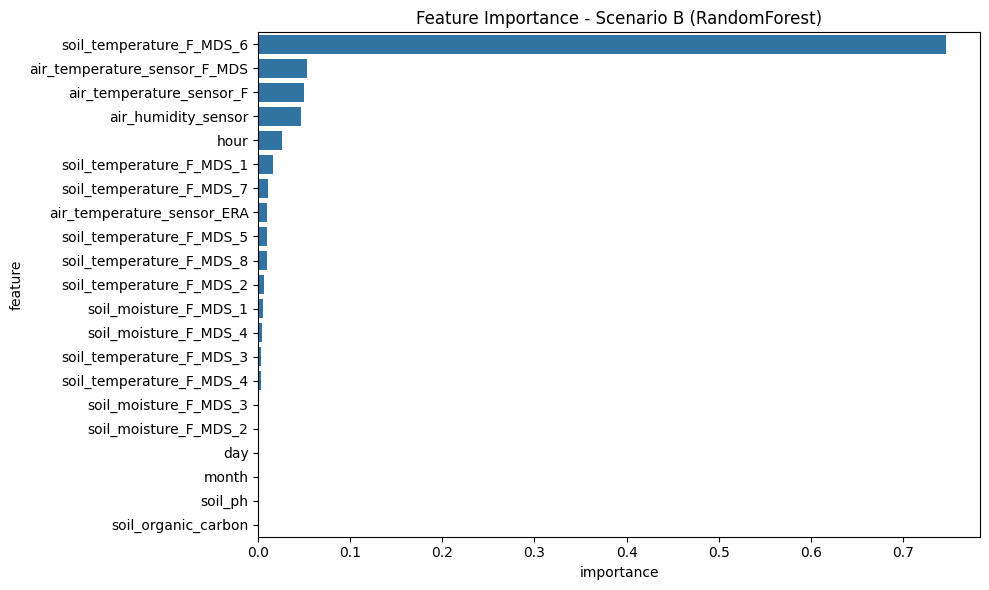

,feature,importance
9,soil_temperature_F_MDS_6,0.746546
0,air_temperature_sensor_F_MDS,0.052828
2,air_temperature_sensor_F,0.049164
3,air_humidity_sensor,0.046563
16,hour,0.025311
4,soil_temperature_F_MDS_1,0.015548
10,soil_temperature_F_MDS_7,0.010093
1,air_temperature_sensor_ERA,0.009619
8,soil_temperature_F_MDS_5,0.009533
11,soil_temperature_F_MDS_8,0.009146


In [6]:
# Feature importance Skenario B
fi_b = plot_feature_importance(
    rf_model_b,
    feature_names=features_b,
    title='Feature Importance - Scenario B (RandomForest)'
)

fi_b.head(15)
